In [ ]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")
print("Path to dataset files:", path)

100%|██████████| 204M/204M [00:00<00:00, 239MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/versions/1


In [ ]:
!ls {path}

auto_test  test  train	val


In [4]:
from torchvision import transforms, datasets

base = path

tf = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train = datasets.ImageFolder(f"{base}/train", transform=tf)
val   = datasets.ImageFolder(f"{base}/val",   transform=tf)
test  = datasets.ImageFolder(f"{base}/test",  transform=tf)

print("train:", len(train), "| val:", len(val), "| test:", len(test))
print("classes:", train.classes)


train: 5778 | val: 826 | test: 1656
classes: ['0', '1', '2', '3', '4']


In [5]:
from collections import Counter

for name, ds in [("train", train), ("val", val), ("test", test)]:
    counts = Counter(ds.targets)
    print(name, {ds.classes[k]: v for k, v in sorted(counts.items())})


train {'0': 2286, '1': 1046, '2': 1516, '3': 757, '4': 173}
val {'0': 328, '1': 153, '2': 212, '3': 106, '4': 27}
test {'0': 639, '1': 296, '2': 447, '3': 223, '4': 51}


In [6]:
import torch

counts = Counter(train.targets)
total = sum(counts.values())
weights = [total / (5 * counts[i]) for i in range(5)]
class_weights = torch.tensor(weights, dtype=torch.float)

print("class weights:", [round(w, 2) for w in weights])


class weights: [0.51, 1.1, 0.76, 1.53, 6.68]


In [7]:
train_tf = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224,224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train = datasets.ImageFolder(f"{base}/train", transform=train_tf)
print("train:", len(train))


train: 5778


In [8]:
from torch.utils.data import DataLoader

val = datasets.ImageFolder(f"{base}/val", transform=tf)
test = datasets.ImageFolder(f"{base}/test", transform=tf)

train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader = DataLoader(val, batch_size=32, shuffle=False)
test_loader = DataLoader(test, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
print("batch shape:", images.shape)
print("labels:", labels[:10])


batch shape: torch.Size([32, 3, 224, 224])
labels: tensor([2, 2, 0, 2, 0, 4, 3, 2, 0, 0])


In [9]:
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader

# 1) دالة التنظيف: noise reduction + تحسين التباين
class Denoise:
    def __call__(self, img):
        g = np.array(img.convert("L"))                      # رمادي
        g = cv2.GaussianBlur(g, (3, 3), 0)                  # إزالة الضوضاء
        g = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(g)  # تحسين التباين
        return Image.fromarray(g)

# 2) pipeline للـ val و test (بدون augmentation)
tf = transforms.Compose([
    Denoise(),
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3) pipeline للـ train (مع augmentation)
train_tf = transforms.Compose([
    Denoise(),
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4) نعيد تحميل الداتا بالـ pipeline الجديد
train = datasets.ImageFolder(f"{base}/train", transform=train_tf)
val   = datasets.ImageFolder(f"{base}/val",   transform=tf)
test  = datasets.ImageFolder(f"{base}/test",  transform=tf)

train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test,  batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
print("batch shape:", images.shape)
print("train:", len(train), "| val:", len(val), "| test:", len(test))


batch shape: torch.Size([32, 3, 224, 224])
train: 5778 | val: 826 | test: 1656


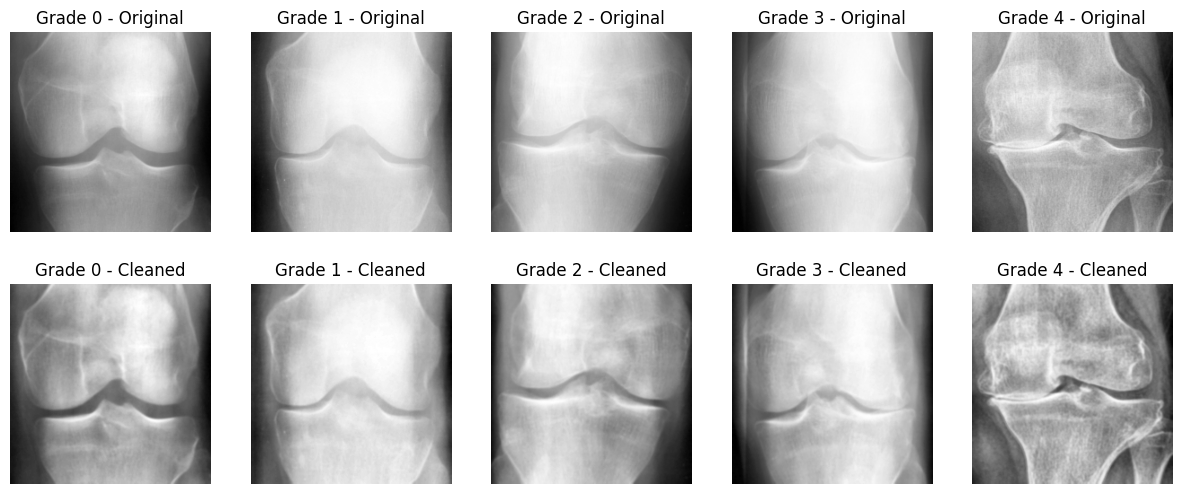

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for k in range(5):
    path_k = train.samples[train.targets.index(k)][0]
    original = Image.open(path_k).convert("L")
    cleaned = Denoise()(original)
    axes[0][k].imshow(original, cmap="gray"); axes[0][k].set_title(f"Grade {k} - Original"); axes[0][k].axis("off")
    axes[1][k].imshow(cleaned, cmap="gray"); axes[1][k].set_title(f"Grade {k} - Cleaned"); axes[1][k].axis("off")
plt.show()

# مو مهم بس عشان اشوف الصور قبل وبعد